# Segmentering av telekomabonnenter med k-means-klustring


## Sammanfattning

En telekomoperatör vill gruppera sin efterbetalda abonnentbas i beteendesegment för att kunna rikta lojalitetserbjudanden och rätt-storleksanpassa dataplaner. Den här notebooken genererar ett syntetiskt abonnentanvändningsdataset och kör sedan en fullständig k-means-segmenteringspipeline i Base SAS: standardisera användningsvariablerna med **PROC STDIZE**, välj antalet kluster genom att jämföra pseudo-F-statistiken för olika kandidat-k med **PROC FASTCLUS**, anpassa en FREKVENS-viktad slutmodell som poängsätter varje abonnent, och exportera de inlärda centroiderna så att nästa månads ögonblicksbild kan poängsättas utan omklustring. Resultatet är en återanvändbar segmentering som översätter rå användningstelemetri till en spelbok för kundlojalitet.

## Datakällor

**Syntetiskt dataset: `WORK.SUBSCRIBERS`** (100 efterbetalda mobilabonnenter, genererade direkt med `call streaminit(20260531)`)

| Variabel | Typ | Roll | Beskrivning |
|----------|------|------|-------------|
| `cust_id` | Tecken | ID | Abonnentidentifierare (t.ex. `SUB000123`) |
| `tenure_months` | Num | Intervallindata | Antal månader linjen varit aktiv (1-72) |
| `data_gb` | Num | Intervallindata | Genomsnittlig månatlig mobildataanvändning, i GB |
| `voice_min` | Num | Intervallindata | Genomsnittliga månatliga röstminuter |
| `intl_min` | Num | Intervallindata | Genomsnittliga månatliga internationella minuter |
| `support_calls` | Num | Intervallindata | Support-/kundtjänstkontakter senaste 90 dagarna |
| `monthly_charge` | Num | Intervallindata | Aktuell månadsfaktura, i dollar |
| `plan_tier` | Tecken | Profilering | Abonnemangsnivå: `Bas`, `Plus` eller `Obegränsad` |
| `n_lines` | Num | FREKVENS-vikt | Antal linjer på kontot |

Tre latenta beteendeprofiler är inbyggda i generatorn - *lätt/prisvärd*, *datatung/streaming* och *hög kontakt/riskkund* - så att klustringen har verklig struktur att återupptäcka. Intervallvariablerna matar k-means-modellen; `plan_tier` hålls utanför för profilering i efterhand, och `n_lines` viktar varje konto efter antal linjer. Inga externa filer eller nätverksåtkomst används.

## Beteendesegmentering i fem steg

Mobiloperatörer har miljontals efterbetalda linjer, och en lojalitetsstrategi som passar alla slösar marginal på kunder som ändå skulle stanna, samtidigt som den missar dem som är på väg att lämna. **Beteendesegmentering** omvandlar rå användningstelemetri till ett fåtal handlingsbara kundtyper: *lätta/prisvärda* användare som är priskänsliga, *datatunga streamers* som är bra uppsäljningsmål, och *hög kontakt/riskkonton* som behöver proaktiv omsorg.

Den här notebooken bygger segmenteringen med `PROC FASTCLUS`, SAS k-means-procedur (disjunkt klustring). Vi kommer att:

1. Generera ett syntetiskt men realistiskt abonnentanvändningsdataset.
2. Sätta användningsvariablerna på en gemensam skala med **PROC STDIZE**.
3. **Välja antalet kluster** genom att jämföra pseudo-F-statistiken för olika kandidat-k.
4. Anpassa en FREKVENS-viktad slutmodell som **poängsätter** varje abonnent och profilerar segmenten.
5. **Exportera de inlärda centroiderna** så att modellen kan återanvändas på nästa månads ögonblicksbild.

## Steg 1 - Generera en syntetisk abonnentbas

Vi simulerar 100 efterbetalda abonnenter. Var och en dras från en av tre latenta profiler med olika användningssignaturer, så att det finns verklig klusterstruktur att återupptäcka. Vi låser slumptalsströmmen med `call streaminit` för reproducerbarhet och begränsar de simulerade värdena till rimliga intervall med `max`/`min`/`round`.

Den nominella `plan_tier` är korrelerad med den latenta profilen (streamers lutar mot *Obegränsad*; prisvärda användare mot *Bas*), och `n_lines` kommer senare att fungera som en FREKVENS-vikt så att flerlinjekonton för familjer räknas proportionellt.

In [1]:
data subscribers;
    CALL streaminit(20260531);
    LÄNGD cust_id $9 plan_tier $12;
    GÖR i = 1 TILL 100;
        cust_id = cats('SUB', SKRIV_UT_V(i, z6.));

        /* Tre latenta beteendeprofiler, ~ojämn förekomst */
        u = rand('uniform');
        OM u < 0.45 SÅ profile = 1;        /* lätt / prisvärd        */
        ANNARS OM u < 0.80 SÅ profile = 2;   /* datatung streamer      */
        ANNARS profile = 3;                    /* hög kontakt / riskkund */

        OM profile = 1 SÅ GÖR;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        SLUT;
        ANNARS OM profile = 2 SÅ GÖR;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        SLUT;
        ANNARS GÖR;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        SLUT;

        /* Abonnemangsnivå korrelerad med profil */
        p = rand('uniform');
        OM profile = 1 SÅ
            plan_tier = ifc(p < 0.70, 'Bas', ifc(p < 0.95, 'Plus', 'Obegränsad'));
        ANNARS OM profile = 2 SÅ
            plan_tier = ifc(p < 0.65, 'Obegränsad', ifc(p < 0.90, 'Plus', 'Bas'));
        ANNARS
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Obegränsad', 'Bas'));

        /* Linjer på kontot: de flesta har en enda linje */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Avrunda monetära / användningsvärden till realistisk precision */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        UTDATA;
    SLUT;
    TA_BORT i u p profile;
KÖR;

PROCEDUR SKRIV data=subscribers(obs=10) noobs;
    ETIKETT cust_id="Kund-ID" tenure_months="Kundlängd (månader)" data_gb="Data (GB)"
          voice_min="Röstminuter" intl_min="Internationella minuter"
          support_calls="Supportärenden" monthly_charge="Månadsavgift"
          plan_tier="Abonnemangsnivå" n_lines="Antal linjer";
    TITEL "Urval av syntetiska abonnentanvändningsposter";
KÖR;


                                     Urval av syntetiska abonnentanvändningsposter                                      

  Kund-ID   Abonnemangsnivå    Kundlängd (månader)  Data (GB)   Röstminuter  Internationella minuter   Supportärenden   Månadsavgift  Antal linjer
SUB000001  Bas                                  15        9.7           114                        5               11          57.07             2
SUB000002  Bas                                  39        0.6           214                        2                1          35.88             3
SUB000003  Obegränsad                           45       23.9           325                        6                1         103.94             2
SUB000004  Bas                                  41        1.9           202                        1                0          61.69             3
SUB000005  Bas                                  34        2.8           112                        4                1          36.91           


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Steg 2 - Sätt variablerna på en gemensam skala

k-means använder euklidiskt avstånd, så en variabel med stor magnitud som röstminuter skulle dominera en med liten magnitud som supportsamtal om vi klustrade på råvärdena. Standardåtgärden är att först standardisera varje intervallvariabel till medelvärde 0 och standardavvikelse 1. **PROC STDIZE** med `METHOD=STD` gör exakt det och skriver den z-poängsatta kopian till `WORK.SUBS_STD`. Vi för `cust_id`, `plan_tier` och `n_lines` vidare orörda så att de finns tillgängliga för viktning och profilering senare.

In [2]:
PROCEDUR stdize data=subscribers out=subs_std METHOD=std;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
KÖR;

PROCEDUR MEDELVÄRDEN data=subs_std mean std maxdec=3;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ETIKETT tenure_months="Kundlängd (månader)" data_gb="Data (GB)" voice_min="Röstminuter"
          intl_min="Internationella minuter" support_calls="Supportärenden"
          monthly_charge="Månadsavgift";
    TITEL "Standardiserade variabler: medelvärde ~ 0, std ~ 1";
KÖR;


                                     Urval av syntetiska abonnentanvändningsposter                                      

                                   Standardiserade variabler: medelvärde ~ 0, std ~ 1                                   

                                                  The MEANS Procedure

 Variable        Label                             Mean     Std Dev
 ------------------------------------------------------------------
 tenure_months   Kundlängd (månader)              0.000       1.000
 data_gb         Data (GB)                       -0.000       1.000
 voice_min       Röstminuter                     -0.000       1.000
 intl_min        Internationella minuter          0.000       1.000
 support_calls   Supportärenden                  -0.000       1.000
 monthly_charge  Månadsavgift                     0.000       1.000
 ------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Steg 3 - Hur många segment? Jämför pseudo-F över kandidat-k

Istället för att gissa antalet kluster anpassar vi FASTCLUS för varje kandidat-k och läser av de anpassningsstatistik som proceduren rapporterar. Både **pseudo-F-statistikan** (kvoten mellan varians mellan kluster och varians inom kluster) och **total R-kvadrat** belönar separation; ett bra k är där pseudo-F är högt och ytterligare ett kluster ger avtagande avkastning. En kort makroloop kör k = 2, 3, 4 med `MAXITER=50` och `CONVERGE=0` (iterera till stabilitet). Jämför raderna `Pseudo F Statistic` och `Overall R-Squared` i de tre listningarna nedan: den inbyggda strukturen har tre latenta profiler, och k = 3 ger den starkaste, mest balanserade lösningen.

In [3]:
%macro pick_k;
    %GÖR k = 2 %TILL 4;
        PROCEDUR FASTCLUS data=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            ETIKETT tenure_months="Kundlängd (månader)" data_gb="Data (GB)" voice_min="Röstminuter"
                  intl_min="Internationella minuter" support_calls="Supportärenden"
                  monthly_charge="Månadsavgift";
            TITEL "Kandidatantal kluster: k = &k";
        KÖR;
    %SLUT;
%mend pick_k;
%pick_k;


                                   Standardiserade variabler: medelvärde ~ 0, std ~ 1                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Steg 4 - Anpassa den slutliga segmenteringen och poängsätt varje abonnent

Med k = 3 valt anpassar vi produktionsmodellen. Den här körningen är helt idiomatisk för en operativ segmentering:

- `FREQ`-satsen viktar varje konto efter `n_lines`, så att ett fyrlinjers familjekonto bidrar fyra gånger så mycket som en enda linje när centroiderna beräknas.
- `OUT=SCORED` skriver varje abonnent med sitt tilldelade `CLUSTER` och sitt `DISTANCE` till det klustrets centroid; `ID`-satsen för med `cust_id` in i den poängsatta tabellen.
- `MEAN=SEG_MEANS` samlar centroiderna per kluster (på den standardiserade skalan).
- `OUTSEED=SEG_SEEDS` sparar de slutliga centroiderna i det seed-format FASTCLUS kan läsa tillbaka - detta är den exporterade modell vi återanvänder i steg 6.

Anpassningsstatistiken fastställdes redan i genomgången i steg 3, så vi lägger till alternativet `SHORT` här för att hålla listningen fokuserad på de klusterstorlekar och centroider som driver poängsättningen.

In [4]:
PROCEDUR FASTCLUS data=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    FREKVENSER n_lines;
    id cust_id;
    ETIKETT tenure_months="Kundlängd (månader)" data_gb="Data (GB)" voice_min="Röstminuter"
          intl_min="Internationella minuter" support_calls="Supportärenden"
          monthly_charge="Månadsavgift" cust_id="Kund-ID" n_lines="Antal linjer";
    TITEL "Slutlig segmentering: k = 3, FREKVENS-viktad efter antal linjer";
KÖR;

PROCEDUR SKRIV data=seg_means noobs;
    TITEL "Segmentcentroider (standardiserad skala)";
KÖR;


                                   Standardiserade variabler: medelvärde ~ 0, std ~ 1                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Steg 5 - Profilera segmenten i affärsenheter

Den poängsatta tabellen bär varje abonnents `CLUSTER`-tilldelning, men på den standardiserade skalan är centroiderna svåra att läsa. För att omvandla klusternummer till affärspersonas kopplar vi tilldelningen tillbaka till den ursprungliga tabellen `subscribers` och profilerar i verkliga enheter - gigabyte, minuter och dollar. PROC MEANS sammanfattar intervallvariablerna per segment, och PROC FREQ korstabellerar den utelämnade `plan_tier` mot segmentet för att visa varje personas abonnemangsmix.

                        Segmentprofiler: genomsnittlig användning per segment (originalenheter)                         

                                                  The MEANS Procedure

                               Analysis Variable : tenure_months Kundlängd (månader)

                                         N
                            Segment    Obs      Mean      Std Dev      Minimum      Maximum
                            ---------------------------------------------------------------
                            1           51      33.2         14.7          1.0         61.0
                            2           31      40.5         14.0         17.0         67.0
                            3           18      12.7          7.1          1.0         30.0
                            ---------------------------------------------------------------

                                        Analysis Variable : data_gb Data (GB)

                                         N
   


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


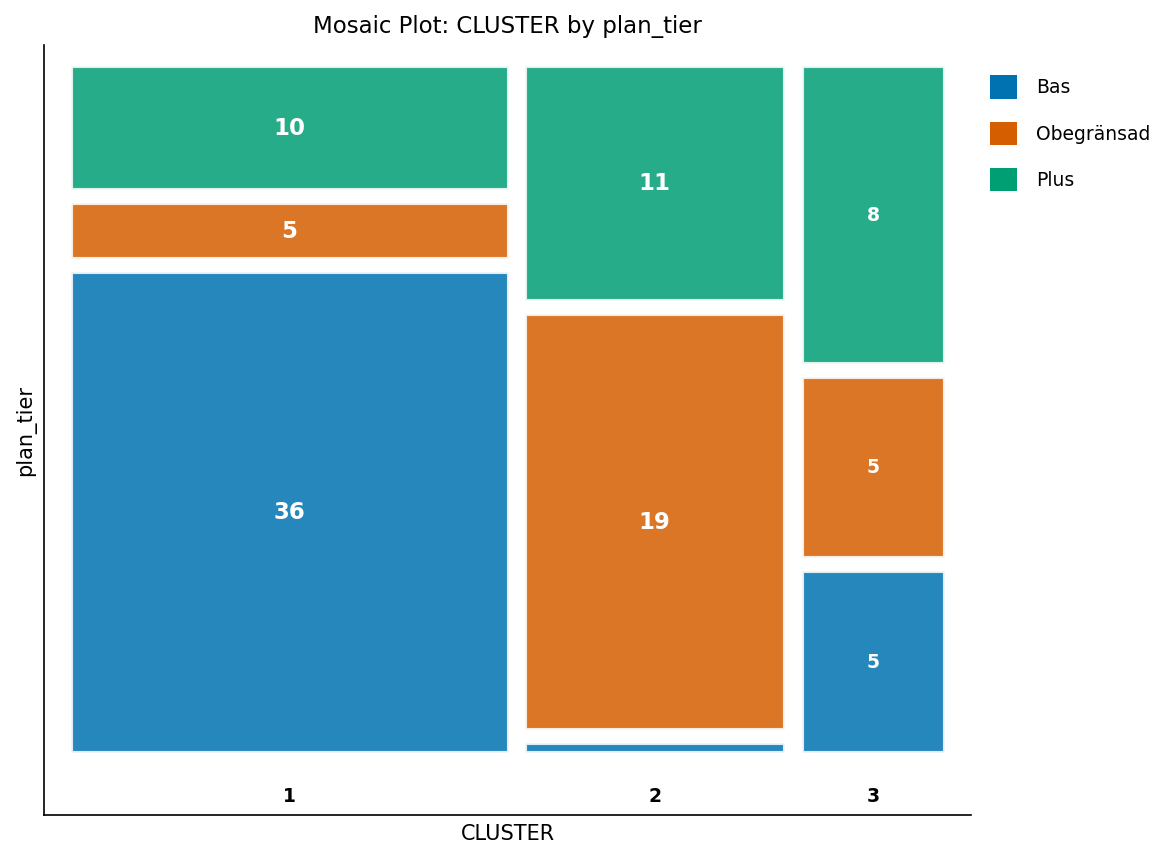

In [5]:
PROCEDUR SORTERA data=scored out=scored_keys(BEHÅLL=cust_id CLUSTER);
    EFTER cust_id;
KÖR;

PROCEDUR SORTERA data=subscribers out=subs_sorted;
    EFTER cust_id;
KÖR;

data profile;
    SAMMANFOGA subs_sorted(IN=a) scored_keys(IN=b);
    EFTER cust_id;
    OM a AND b;
KÖR;

PROCEDUR MEDELVÄRDEN data=profile mean std MIN MAX maxdec=1;
    KLASS CLUSTER;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    ETIKETT CLUSTER="Segment" tenure_months="Kundlängd (månader)" data_gb="Data (GB)"
          voice_min="Röstminuter" intl_min="Internationella minuter"
          support_calls="Supportärenden" monthly_charge="Månadsavgift";
    TITEL "Segmentprofiler: genomsnittlig användning per segment (originalenheter)";
KÖR;

PROCEDUR FREKVENSER data=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    ETIKETT CLUSTER="Segment" plan_tier="Abonnemangsnivå";
    TITEL "Abonnemangsmix inom varje segment";
KÖR;


## Steg 6 - Återanvänd modellen på nästa månads ögonblicksbild

En segmentering är bara användbar om den kan återanvändas utan att köra om hela jobbet. Centroiderna vi sparade till `SEG_SEEDS` i steg 4 är en portabel modell: att mata in dem igen som `SEED=SEG_SEEDS` med `MAXITER=0` säger åt FASTCLUS att *tilldela* varje observation till sin närmaste sparade centroid utan att flytta centroiderna - ren poängsättning, inte omanpassning. Här poängsätter vi samma standardiserade ögonblicksbild igen för att bekräfta att den exporterade modellen återskapar de ursprungliga tilldelningarna; i produktion skulle du istället peka `DATA=` på nästa månads standardiserade ögonblicksbild.

                                           Abonnemangsmix inom varje segment                                            


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


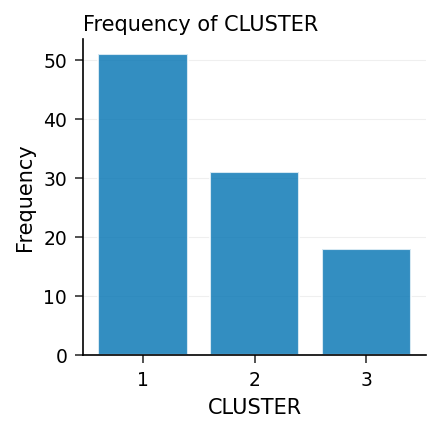

In [6]:
PROCEDUR FASTCLUS data=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    VARIABEL tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    ETIKETT tenure_months="Kundlängd (månader)" data_gb="Data (GB)" voice_min="Röstminuter"
          intl_min="Internationella minuter" support_calls="Supportärenden"
          monthly_charge="Månadsavgift" cust_id="Kund-ID";
    TITEL "Poängsättning av en ny ögonblicksbild från de exporterade centroiderna";
KÖR;

PROCEDUR FREKVENSER data=rescored;
    TABLES CLUSTER / nocum;
    ETIKETT CLUSTER="Segment";
    TITEL "Abonnenter ompoängsatta via den exporterade modellen";
KÖR;


## Tolkning av resultaten

FASTCLUS återupptäckte de tre beteendesegment som var inbyggda i datat, och profileringstabellerna översätter dem till en spelbok för kundlojalitet. Läs av segmentnumren i tabellen *Segmentprofiler* ovan - klusteretiketterna är godtyckliga, så identifiera varje persona utifrån dess användningssignatur:

- **Lätta/prisvärda användare** - låg dataanvändning, blygsamma fakturor, längre kundlängd, mycket få supportsamtal, mestadels på *Bas*. Dessa kunder är stabila och priskänsliga; rätt drag är att *skydda marginalen*, inte rabattera. En rätt-storleksanpassad abonnemangsrekommendation förhindrar fakturachock utan att ge bort värde.
- **Datatunga streamers** - hög dataanvändning, höga röst- och internationella minuter, premiumfakturor, mestadels *Obegränsad*. De är lojala och högvärdiga: draget är *uppförsäljning och enhetsuppgraderingar*, plus proaktiva meddelanden om nätverkskvalitet så att en konkurrents erbjudande inte kan locka bort dem.
- **Hög kontakt / riskkunder** - kort kundlängd, förhöjd volym supportsamtal, medelnivåspendering. De frekventa vårdkontakterna plus den korta kundlängden är klassiska förvarningstecken på churn. Detta är segmentet som förtjänar ett *proaktivt lojalitetserbjudande* och en uppföljning för tjänsteåterhämtning.

Viktiga procedurval som gjorde detta tillförlitligt: **PROC STDIZE** hindrade röstminuter med stor magnitud från att dränka supportsamtalssignalen; pseudo-F-genomgången motiverade antalet kluster istället för att gissa det; `FREQ`-vikten gjorde att flerlinjekonton för familjer räknades i proportion till sin storlek; och `OUTSEED=`/`SEED=`-tur-och-retur exporterade centroiderna så att marknadsföringsteamet kan omsegmentera varje månatlig ögonblicksbild med ett enda `MAXITER=0`-anrop av FASTCLUS - ingen omklustring krävs.